# Importing other groups data, formatting it in the form of our dataframes

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#importing other groups data to get it in form of our data
df_altinside = pd.read_csv("altindoor.csv")
df_altoutside = pd.read_csv("altoutdoor.csv")

target_columns = [
    "time",
    "PM2.5 env",
    "particles 2.5um",
    "Temperature",
    "Gas",
    "Humidity",
    "Pressure",
    "Altitude",
]


df_altinside = df_altinside.rename(columns={
    "Timestamp" : "time",
    "Temp":"Temperature",
    "PM25_Env": "PM2.5 env"
})
df_altoutside = df_altoutside.rename(columns={
    "Timestamp" : "time",
    "Temp":"Temperature",
    "PM25_Env": "PM2.5 env"
})

for col in target_columns:
    if col not in df_altinside.columns:
        df_altinside[col] = 0
        df_altinside[col] = 0
    if col not in df_altoutside.columns:
        df_altoutside[col] = 0
        df_altoutside[col] = 0


        
df_altinside = df_altinside[target_columns]
df_altoutside = df_altoutside[target_columns]


# Importing other group and our data, cutting out very beginning to account for spikes/going outside

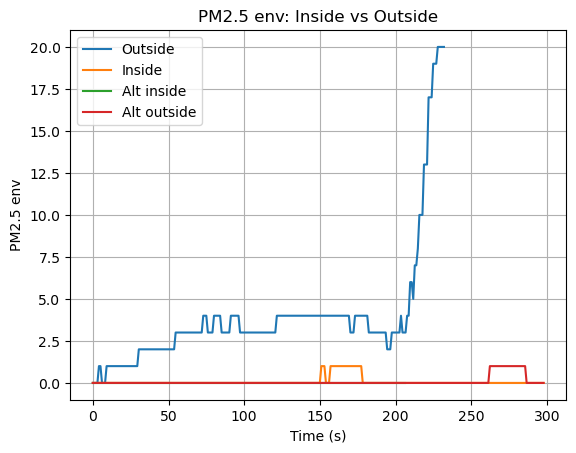

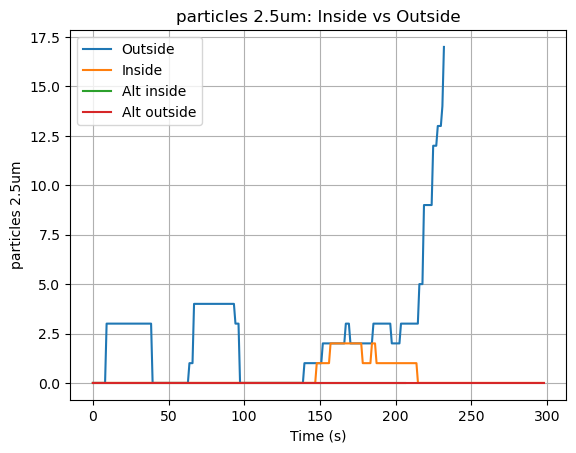

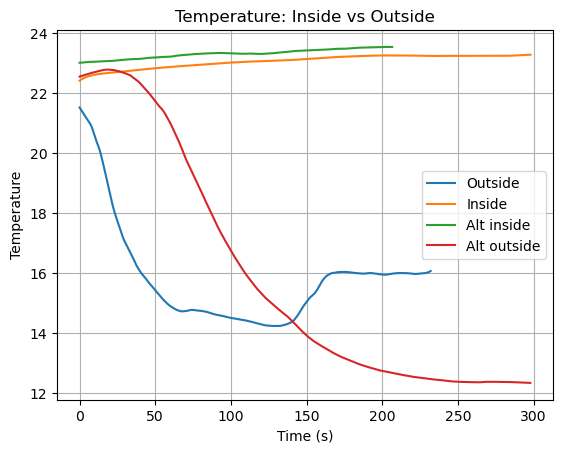

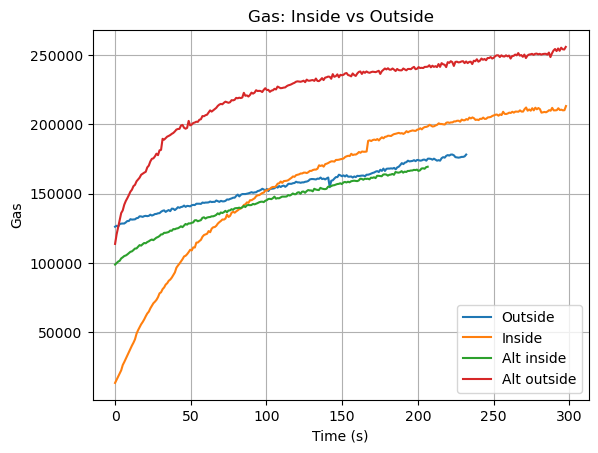

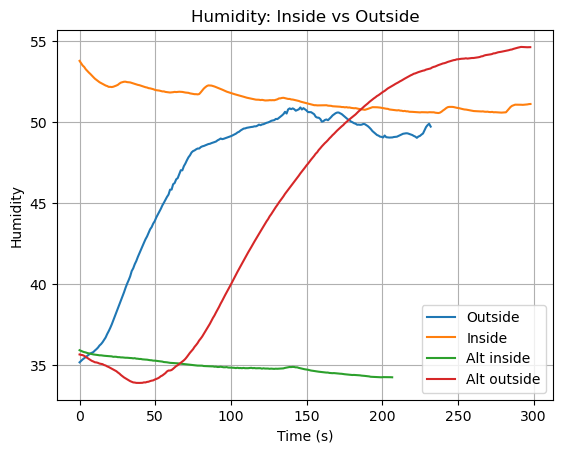

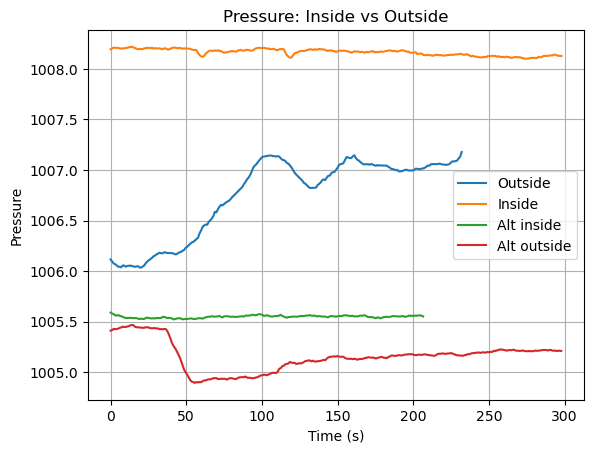

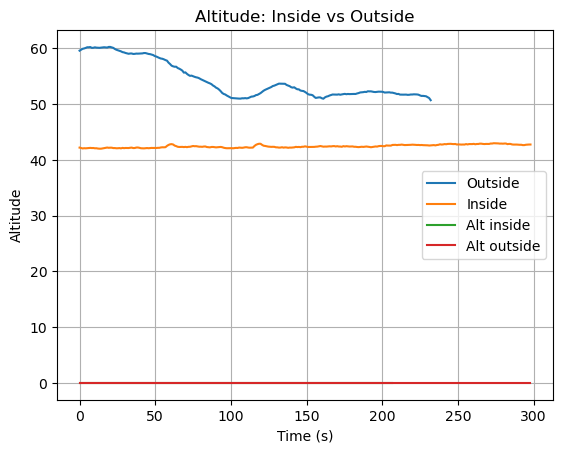

,time,PM2.5 env,particles 2.5um,Temperature,Gas,Humidity,Pressure,Altitude
17,0.000000,0,0,23.007344,98923,35.920351,1005.590217,0
18,1.012023,0,0,23.010469,99986,35.875845,1005.580387,0
19,2.025198,0,0,23.016133,101071,35.837196,1005.574975,0
20,3.037870,0,0,23.021797,101652,35.804154,1005.562777,0
21,4.049309,0,0,23.028437,103375,35.782406,1005.560761,0
...,...,...,...,...,...,...,...,...
217,202.461247,0,0,23.534102,168132,34.265026,1005.559615,0
218,203.474014,0,0,23.534492,168292,34.253973,1005.561992,0
219,204.486713,0,0,23.534883,167972,34.254009,1005.562671,0
220,205.499957,0,0,23.534492,169097,34.253973,1005.558596,0


In [7]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#importing other groups data to get it in form of our data
df_altinside = pd.read_csv("altindoor.csv")
df_altoutside = pd.read_csv("altoutdoor.csv")

target_columns = [
    "time",
    "PM2.5 env",
    "particles 2.5um",
    "Temperature",
    "Gas",
    "Humidity",
    "Pressure",
    "Altitude",
]


df_altinside = df_altinside.rename(columns={
    "Timestamp" : "time",
    "Temp":"Temperature",
    "PM25_Env": "PM2.5 env"
})
df_altoutside = df_altoutside.rename(columns={
    "Timestamp" : "time",
    "Temp":"Temperature",
    "PM25_Env": "PM2.5 env"
})

for col in target_columns:
    if col not in df_altinside.columns:
        df_altinside[col] = 0
        df_altinside[col] = 0
    if col not in df_altoutside.columns:
        df_altoutside[col] = 0
        df_altoutside[col] = 0


        
df_altinside = df_altinside[target_columns]
df_altoutside = df_altoutside[target_columns]





#####################

# OUR DATA
#####################


#importing our data for indoor, outdoor, and vent

df_inside = pd.read_csv("indoortest.csv")
df_outside = pd.read_csv("simpletest.csv")
df_vent = pd.read_csv("newoutdoortest.csv")

time = 'time'
#shift all the dataframes so the time starts at 0, cut out first 5 seconds

#outside
df_outside[time] = df_outside[time] - df_outside[time].iloc[0]
df_outside = df_outside[df_outside[time] > 70]
df_outside[time] = df_outside[time] - df_outside[time].iloc[0]

df_inside[time] = df_inside[time] - df_inside[time].iloc[0]
df_inside = df_inside[df_inside[time] > 5]
df_inside[time] = df_inside[time] - df_inside[time].iloc[0]

#vent
df_vent[time] = df_vent[time] - df_vent[time].iloc[0]
df_vent = df_vent[df_vent[time] > 90]
df_vent[time] = df_vent[time] - df_vent[time].iloc[0]

#other groups outside
df_altoutside[time] = df_altoutside[time] - df_altoutside[time].iloc[0]
df_altoutside = df_altoutside[df_altoutside[time] > 5]
df_altoutside[time] = df_altoutside[time] - df_altoutside[time].iloc[0]
#get only first 5 minutes
df_altoutside = df_altoutside[df_altoutside[time] <=300]

#other groups inside
df_altinside[time] = df_altinside[time] - df_altinside[time].iloc[0]
df_altinside = df_altinside[df_altinside[time] > 18]
df_altinside[time] = df_altinside[time] - df_altinside[time].iloc[0]
#get only first 5 minutes

#plotting all columns but the time column
data_columns = [col for col in df_inside.columns if col != time]

for col in data_columns:
    plt.figure()
    #plot the outside data
    if col in df_outside.columns:
        plt.plot(df_outside[time], df_outside[col], label="Outside")
    #plot the inside data
    if col in df_inside.columns:
        plt.plot(df_inside[time], df_inside[col], label="Inside")

    #plot other groups inside data
    if col in df_altinside.columns:
        plt.plot(df_altinside[time],df_altinside[col],
                 label="Alt inside")

    #plot other groups outside data
    if col in df_altoutside.columns:
        plt.plot(df_altoutside[time], df_altoutside[col], label="Alt outside")

    """
    if col in df_vent.columns:
        plt.plot(df_vent[time_column],
                 df_vent[col],
                 label="Vent")
    """
        
    plt.xlabel("Time (s)")
    plt.ylabel(col)
    plt.title(f"{col}: Inside vs Outside")
    plt.legend()
    plt.grid(True)
    plt.show()



display(df_altinside)

# histograms of our indoor vs. outdoor data

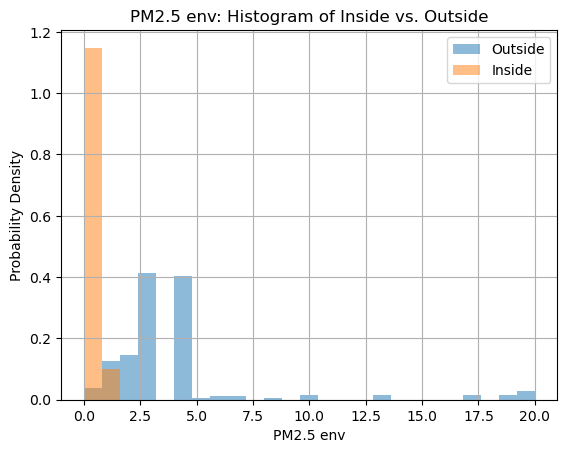

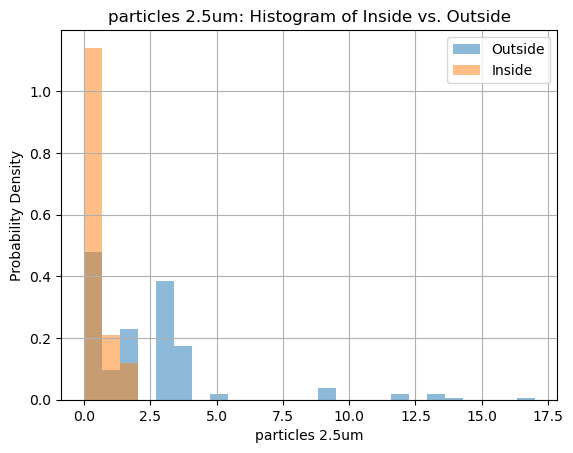

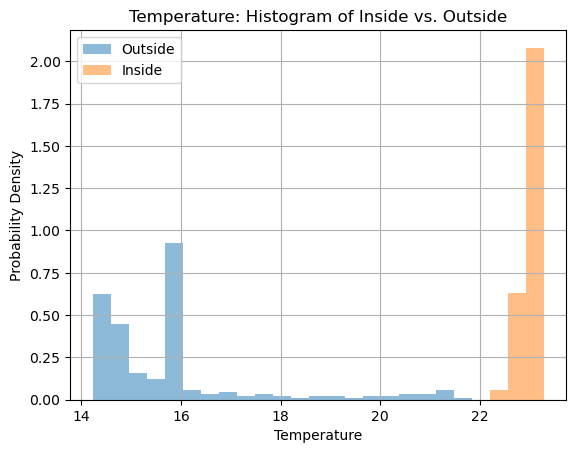

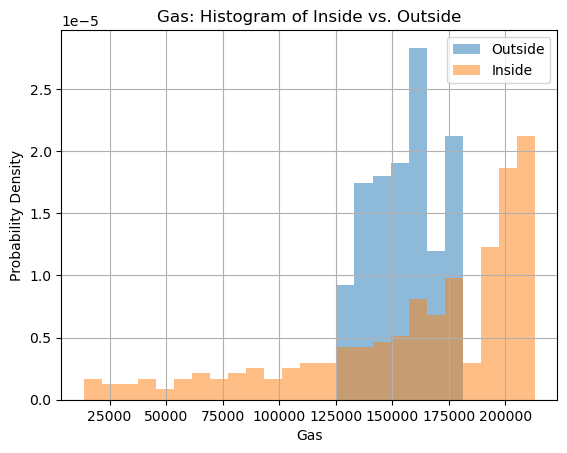

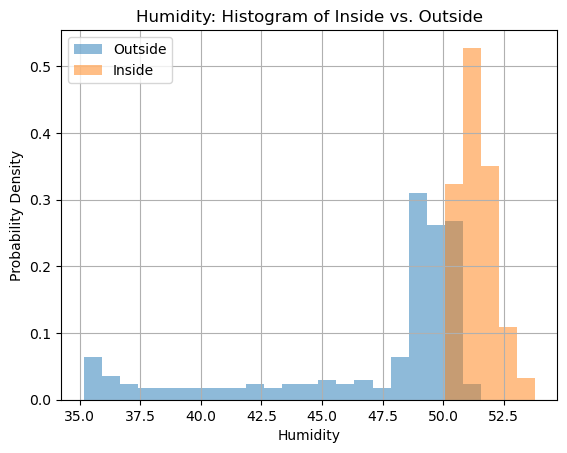

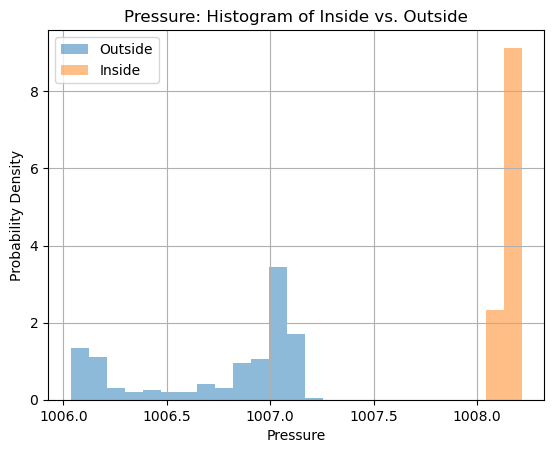

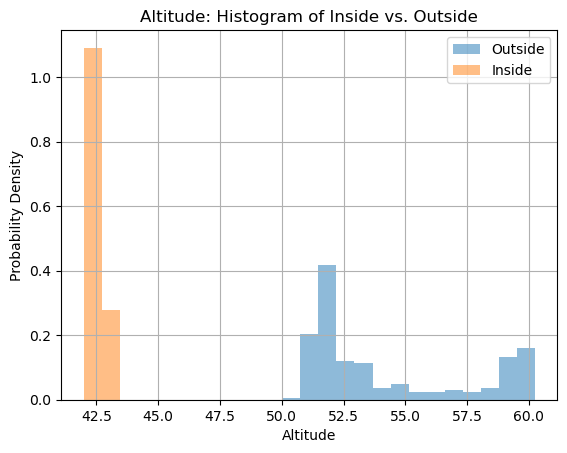

In [3]:
import matplotlib.pyplot as plt
import numpy as np

data_columns = [col for col in df_inside.columns if col != time] #get only non time columns

for col in data_columns: #get histograms of each column
    plt.figure()
    #first gotta find the bins that will make this data readable

    totaldata = []
    totaldata.append(df_outside[col])
    totaldata.append(df_inside[col])
    #get into one array so we can get proper bins
    totaldata = np.concatenate(totaldata)
    bins = np.histogram_bin_edges(totaldata,bins=25)
    
    if col in df_outside.columns:
        plt.hist(df_outside[col], bins=bins, alpha=0.5, label="Outside", density=True)
    
    if col in df_inside.columns:
        plt.hist(df_inside[col], bins=bins, alpha=0.5, label="Inside", density=True)
    #ignore the vent reading for now
    """
    if col in df_vent.columns:
        plt.hist(df_vent[col], bins=bins, alpha=0.5, label="Vent", density=True)
    """
    plt.xlabel(col)
    plt.ylabel("Probability Density")
    plt.title(f"{col}: Histogram of Inside vs. Outside")
    plt.legend()
    plt.grid(True)
    plt.show()

# data analysis

In [4]:


results = []
for col in df_inside[1:]: #for each column do analysis on it, skipping time
    xin = df_inside[col].to_numpy() #get into numpy arrays
    xout = df_outside[col].to_numpy()

    Nin, Nout = len(xin), len(xout)
    
    mu_in, mu_out = xin.mean(), xout.mean()

    #standard deviation
    sigma_in  = xin.std(ddof=1)
    sigma_out = xout.std(ddof=1)

    #mean uncertainty
    sigma_in_uncertainty  = sigma_in / np.sqrt(Nin)
    sigma_out_uncertainty = sigma_out / np.sqrt(Nout)

    #how many inside measurement mean uncertainties away are the two means
    sigma_difference = np.abs(mu_in-mu_out)/sigma_in_uncertainty

    results.append({
        "Column": col,
        "N_in": Nin,
        "N_out": Nout,
        "Mean_in": mu_in,
        "Mean_out": mu_out,
        "Std_in": sigma_in,
        "Std_out": sigma_out,
        "Mean_uncertainty_in": sigma_in_uncertainty,
        "Mean_uncertainty_in": sigma_out_uncertainty,
        "Inside_sigma_difference": sigma_difference
    })

results = pd.DataFrame(results)
display(results)



,Column,N_in,N_out,Mean_in,Mean_out,Std_in,Std_out,Mean_uncertainty_in,Inside_sigma_difference
0,time,295,230,148.941456,115.983603,86.431363,67.393763,4.443813,6.549355
1,PM2.5 env,295,230,0.081356,3.986957,0.273845,3.829876,0.252535,244.958911
2,particles 2.5um,295,230,0.305085,2.391304,0.613184,2.804225,0.184905,58.435976
3,Temperature,295,230,23.058977,15.839549,0.211155,1.686972,0.111236,587.235101
4,Gas,295,230,160057.294915,155016.117391,50970.548032,14437.940615,952.009612,1.698727
5,Humidity,295,230,51.399048,46.964084,0.687486,4.663590,0.307508,110.799343
6,Pressure,295,230,1008.163954,1006.750127,0.031881,0.389976,0.025714,761.675011
7,Altitude,295,230,42.431124,54.257487,0.266520,3.264173,0.215233,762.137239


From our data, it is clear that it is not a gaussian distribution. I believe we would need to collect much more data in a more consistent environment to be considered a gaussian. The central limit theorem could apply to these means, as the sample size when we calculate a mean is far above 30, the general rule of thumb minimum samples needed.

# Histogram and stats comparing to other group (Graphs at top of page)

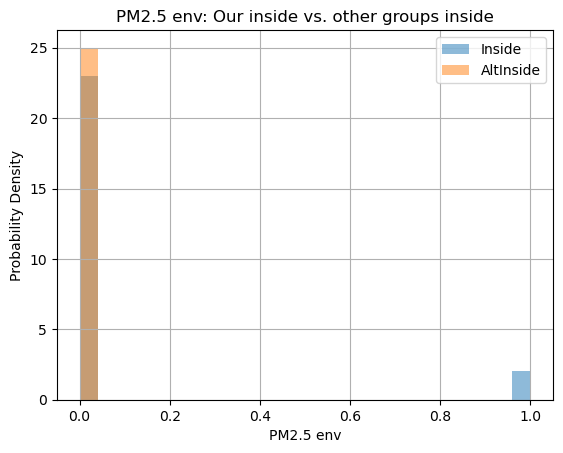

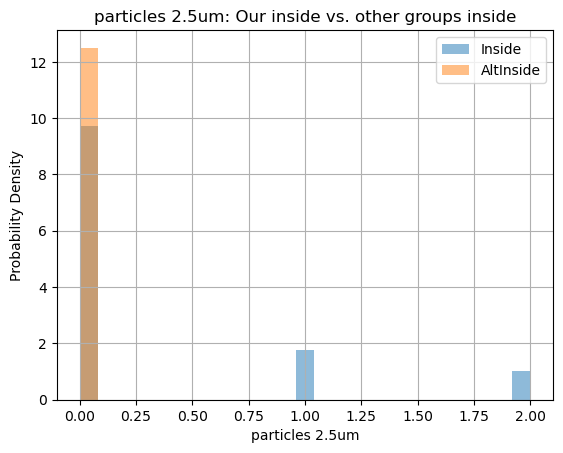

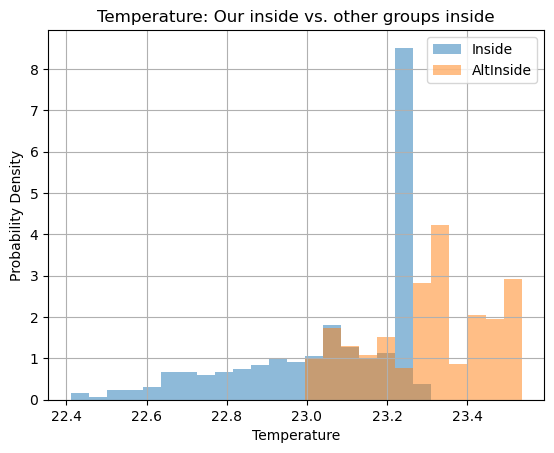

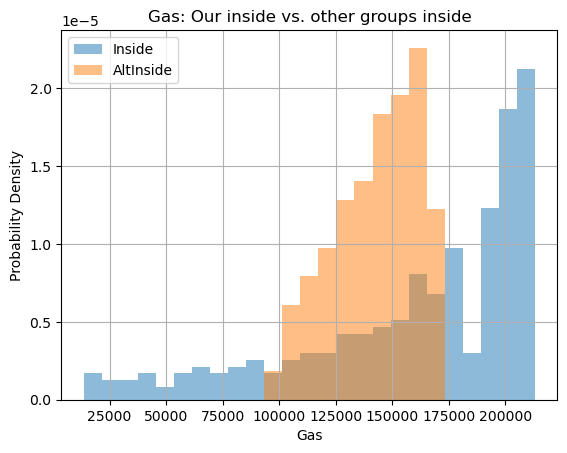

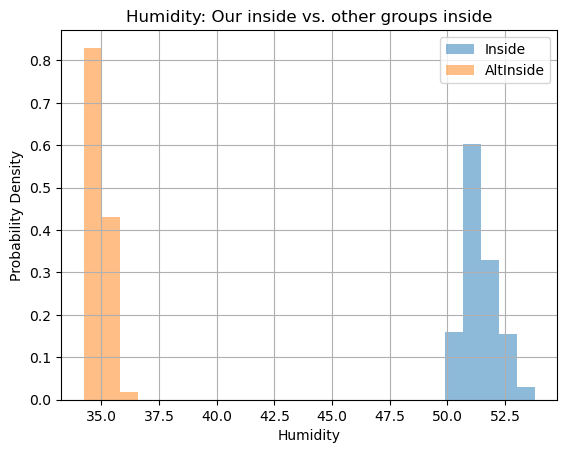

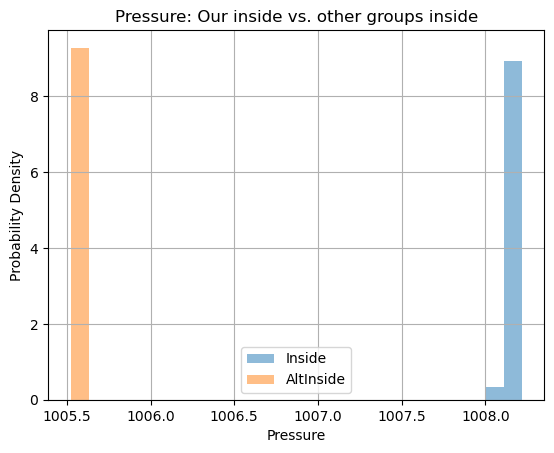

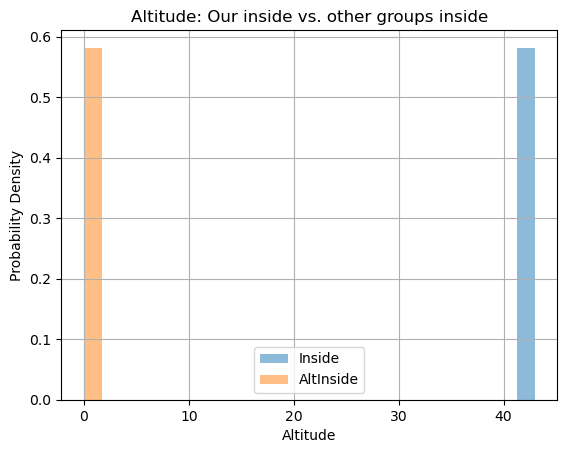

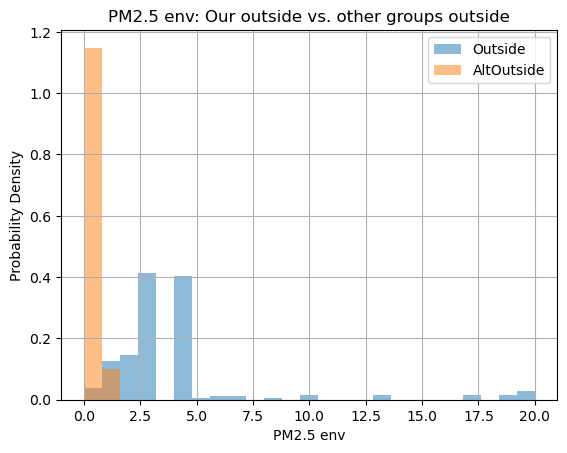

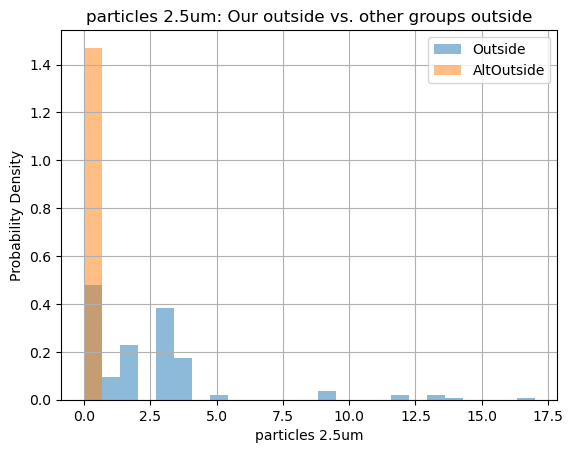

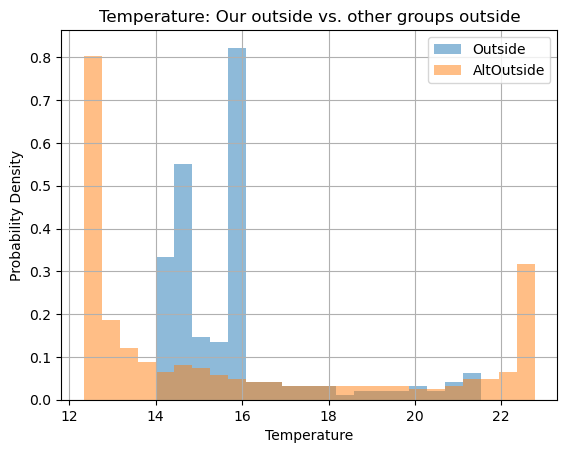

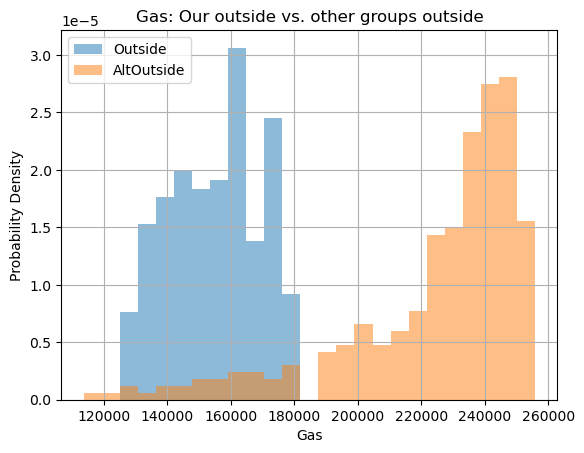

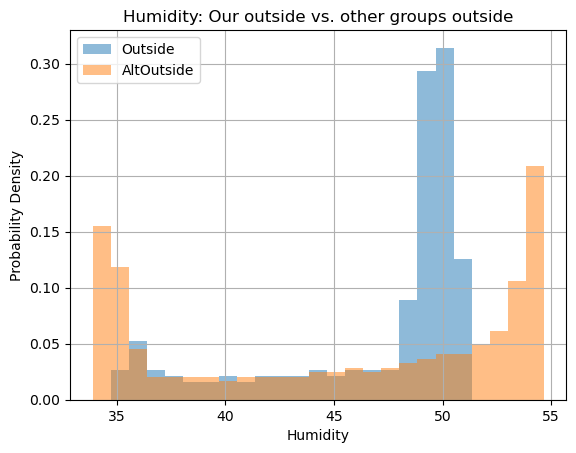

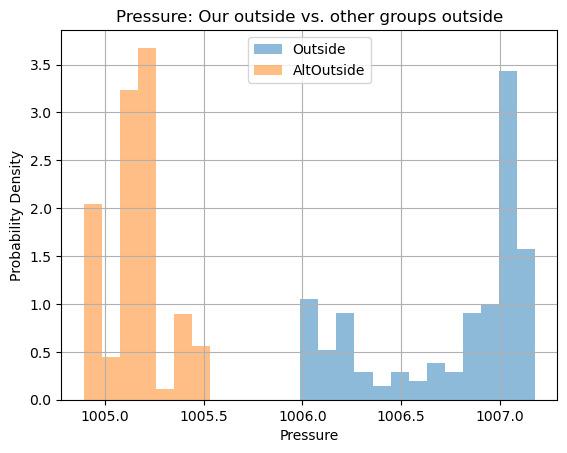

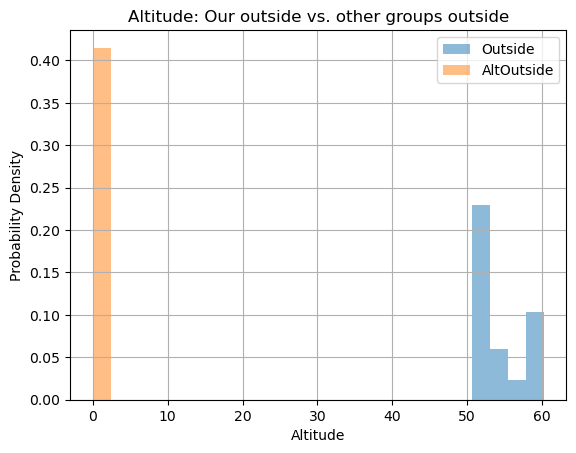

In [5]:
data_columns = [col for col in df_inside.columns if col != time] #get only non time columns


#first do inside, then do outside
for col in data_columns: #get histograms of each column
    plt.figure()
    #first gotta find the bins that will make this data readable

    totaldata = []
    totaldata.append(df_inside[col].dropna())
    totaldata.append(df_altinside[col].dropna())
    #get into one array so we can get proper bins
    totaldata = np.concatenate(totaldata)
    bins = np.histogram_bin_edges(totaldata,bins=25)
    
    if col in df_inside.columns:
        plt.hist(df_inside[col], bins=bins, alpha=0.5, label="Inside", density=True)
    
    if col in df_altinside.columns:
        plt.hist(df_altinside[col].dropna(), bins=bins, alpha=0.5, label="AltInside", density=True)
    #ignore the vent reading for now
   
    plt.xlabel(col)
    plt.ylabel("Probability Density")
    plt.title(f"{col}: Our inside vs. other groups inside")
    plt.legend()
    plt.grid(True)
    plt.show()

for col in data_columns: #get histograms of each column
    plt.figure()
    #first gotta find the bins that will make this data readable

    totaldata = []
    totaldata.append(df_outside[col])
    totaldata.append(df_altoutside[col])
    #get into one array so we can get proper bins
    totaldata = np.concatenate(totaldata)
    bins = np.histogram_bin_edges(totaldata,bins=25)
    
    if col in df_outside.columns:
        plt.hist(df_outside[col], bins=bins, alpha=0.5, label="Outside", density=True)
    
    if col in df_inside.columns:
        plt.hist(df_altoutside[col], bins=bins, alpha=0.5, label="AltOutside", density=True)
    #ignore the vent reading for now
   
    plt.xlabel(col)
    plt.ylabel("Probability Density")
    plt.title(f"{col}: Our outside vs. other groups outside")
    plt.legend()
    plt.grid(True)
    plt.show()

# Data analysis comparing both inside and outside with other group

In [6]:

#inside
results = []
for col in df_inside[1:]: #for each column do analysis on it, skipping time
    xin = df_inside[col].to_numpy() #get into numpy arrays
    xout = df_altinside[col].to_numpy()

    Nin, Nout = len(xin), len(xout)
    
    mu_in, mu_out = xin.mean(), xout.mean()

    #standard deviation
    sigma_in  = xin.std(ddof=1)
    sigma_out = xout.std(ddof=1)

    #mean uncertainty
    sigma_in_uncertainty  = sigma_in / np.sqrt(Nin)
    sigma_out_uncertainty = sigma_out / np.sqrt(Nout)

    #how many inside measurement mean uncertainties away are the two means
    sigma_difference = np.abs(mu_in-mu_out)/sigma_in_uncertainty

    results.append({
        "Column": col,
        "N_inside": Nin,
        "N_altinside": Nout,
        "Mean_inside": mu_in,
        "Mean_altinside": mu_out,
        "Std_inside": sigma_in,
        "Std_altinside": sigma_out,
        "Mean_uncertainty_inside": sigma_in_uncertainty,
        "Mean_uncertainty_altinside": sigma_out_uncertainty,
        "Inside_sigma_difference": sigma_difference
    })

results = pd.DataFrame(results)

print("Inside statistics")
display(results)


#outside

results = []
for col in df_inside[1:]: #for each column do analysis on it, skipping time
    xin = df_outside[col].to_numpy() #get into numpy arrays
    xout = df_altoutside[col].to_numpy()

    Nin, Nout = len(xin), len(xout)
    
    mu_in, mu_out = xin.mean(), xout.mean()

    #standard deviation
    sigma_in  = xin.std(ddof=1)
    sigma_out = xout.std(ddof=1)

    #mean uncertainty
    sigma_in_uncertainty  = sigma_in / np.sqrt(Nin)
    sigma_out_uncertainty = sigma_out / np.sqrt(Nout)

    #how many inside measurement mean uncertainties away are the two means
    sigma_difference = np.abs(mu_in-mu_out)/sigma_in_uncertainty

    results.append({
        "Column": col,
        "N_outside": Nin,
        "N_altoutside": Nout,
        "Mean_outside": mu_in,
        "Mean_altoutside": mu_out,
        "Std_outside": sigma_in,
        "Std_altoutside": sigma_out,
        "Mean_uncertainty_outside": sigma_in_uncertainty,
        "Mean_uncertainty_altoutside": sigma_out_uncertainty,
        "Mean_sigma_difference": sigma_difference
    })

results = pd.DataFrame(results)
print("Outside statistics")
display(results)


Inside statistics


,Column,N_inside,N_altinside,Mean_inside,Mean_altinside,Std_inside,Std_altinside,Mean_uncertainty_inside,Mean_uncertainty_altinside,Inside_sigma_difference
0,time,295,205,148.941456,103.247640,86.431363,60.054743,5.032228,4.194405,9.080235
1,PM2.5 env,295,205,0.081356,0.000000,0.273845,0.000000,0.015944,0.000000,5.102637
2,particles 2.5um,295,205,0.305085,0.000000,0.613184,0.000000,0.035701,0.000000,8.545565
3,Temperature,295,205,23.058977,23.304924,0.211155,0.150796,0.012294,0.010532,20.005536
4,Gas,295,205,160057.294915,142668.995122,50970.548032,18512.260029,2967.620040,1292.952325,5.859342
5,Humidity,295,205,51.399048,34.930737,0.687486,0.422224,0.040027,0.029489,411.430159
6,Pressure,295,205,1008.163954,1005.549078,0.031881,0.011980,0.001856,0.000837,1408.718893
7,Altitude,295,205,42.431124,0.000000,0.266520,0.000000,0.015517,0.000000,2734.427970


Outside statistics


,Column,N_outside,N_altoutside,Mean_outside,Mean_altoutside,Std_outside,Std_altoutside,Mean_uncertainty_outside,Mean_uncertainty_altoutside,Mean_sigma_difference
0,time,230,295,115.983603,148.863996,67.393763,86.389459,4.443813,5.029789,7.399139
1,PM2.5 env,230,295,3.986957,0.081356,3.829876,0.273845,0.252535,0.015944,15.465609
2,particles 2.5um,230,295,2.391304,0.000000,2.804225,0.000000,0.184905,0.000000,12.932601
3,Temperature,230,295,15.839549,15.882845,1.686972,3.896284,0.111236,0.226850,0.389227
4,Gas,230,295,155016.117391,224643.216949,14437.940615,28550.714091,952.009612,1662.286841,73.136971
5,Humidity,230,295,46.964084,45.270916,4.663590,7.823527,0.307508,0.455503,5.506093
6,Pressure,230,295,1006.750127,1005.156449,0.389976,0.146176,0.025714,0.008511,61.976507
7,Altitude,230,295,54.257487,0.000000,3.264173,0.000000,0.215233,0.000000,252.086949


# Comparing sensors commentary

From this data, we can make many inferences about the sensors each of our groups used. 

For inside, starting with temperature, our sensors were quite accurate, both having a mean within 0.3 degrees of eachother. This does present some offset, however, since the means are both outside of each others standard deviation. For gas, our measurements were quite inconsistent, presenting a high standard deviation compared to the other group. This could have been due to the sensor being near one of our breaths when we took the data, or other environmental factors since the data was taken on different days. Our sensor also showed a much higher humidity but with a small standard deviation, showing that perhaps the room was a much higher humidity when we took our measurements vs. when the other group took theirs.

Overall, for the inside data, our sensors seemed (outside of the gas measurement) relatively precise and not very offset from the other group's sensor. 

As for the outdoor measurements, there was a lot more variation in the measurements. For one, the other group seemed to have far more variation in their temperature measurements. Though we are not sure where they went, it is clear that they their sensor took far longer to cool down compared to ours from the initial graph. Other than that, it is more difficult to directly compare our sensors since they were taken on different days, but our pressure sensors seemed to be very accurate.